# Hydrophone calibration curves

Plots the sensitivity curve pbp applies for a hydrophone deployment, built from
`metadata/cal_specs/` with the same code as `cal-to-nc build`, so what you see is what the
spectrograms get. Styled after the ONC HydroCal plots.

- **orange**: the manufacturer's table, as transcribed into the spec
- **red x**: the manufacturer's "Sensitivity @ 26 Hz" reference value (`lf_sens`), when transcribed
- **black**: the curve pbp applies. Below the table it is a first-order high-pass at
  `lf_corner_hz` through the 26 Hz value; without `lf_sens` it is a flat copy of the first table point
- **grey band**: the band in the products (`--freq-lims`, 10 Hz - 30 kHz by default)

`plot_cal(refdes, deployment)` plots one deployment; `preview_lf_sens=` shows what a 26 Hz
value would do before it goes into the spec. The last cell sanity-checks every spec.

In [1]:
import math
import textwrap
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from ooi_hyd_tools.cal_to_nc import HydCal, load_spec, dataset_for

SPEC_DIR = Path("../metadata/cal_specs")
FREQ_LIMS = (10, 30_000)  # acoustic-pipeline --freq-lims default
COUNTS_PER_VOLT_DB = 20 * math.log10(2**23 / 3)  # 24-bit ADC, +-3 V full scale = 128.93 dB

In [2]:
def plot_cal(refdes, deployment, ax=None, preview_lf_sens=None):
    """plot one deployment's calibration curve as pbp applies it"""
    spec_path = SPEC_DIR / f"{refdes}.yaml"
    cal = load_spec(spec_path).deployments[str(deployment)]
    if preview_lf_sens is not None:
        cal = HydCal(**{**cal.model_dump(), "lf_sens": preview_lf_sens})  # re-validated
    ds = cal.to_dataset(spec_path)
    single = ax is None
    if single:
        _, ax = plt.subplots(figsize=(8, 5))

    # the manufacturer table, as printed
    table_f = np.array(cal.frequencies)
    if cal.sens is not None:
        ax.plot(table_f, cal.sens, "o-", color="tab:orange", ms=4, label="Manufacturer")
    else:
        avg = (np.array(cal.sens0) + np.array(cal.sens90)) / 2
        ax.plot(table_f, avg, "o-", color="tab:orange", ms=4, label="Manufacturer (0/90 average)")
        ax.plot(table_f, cal.sens0, ":", color="tab:orange", lw=1, alpha=0.6, label="0 / 90 degree")
        ax.plot(table_f, cal.sens90, ":", color="tab:orange", lw=1, alpha=0.6)
    if cal.lf_sens is not None:
        ax.plot(cal.lf_freq_hz, cal.lf_sens, "x", color="tab:red", ms=9, mew=2, zorder=5,
                label=f"Manufacturer's LF reference value ({cal.lf_freq_hz:g} Hz)")

    # the curve pbp applies: its linear interp between the cal file's points
    f = np.logspace(0, math.log10(table_f[-1]), 600)
    ax.plot(f, ds.sensitivity.interp(frequency=f), "k", lw=1.5,
            label="Curve pbp applies" + (" (preview)" if preview_lf_sens is not None else ""))

    ax.axvspan(*FREQ_LIMS, color="0.92", zorder=0)
    ax.set_xscale("log")
    ax.set_xlim(1, 1e6)
    ax.grid(True, which="both", lw=0.4, alpha=0.6)
    ax.set_xlabel("Frequency [Hz]")
    ax.set_ylabel("Sensitivity [dB re V/$\\mu$Pa]")
    ax.secondary_yaxis("right", functions=(lambda s: s + COUNTS_PER_VOLT_DB,
                                           lambda c: c - COUNTS_PER_VOLT_DB)).set_ylabel("[dB re counts/$\\mu$Pa]")

    cert = f"cert {cal.cal_date:%Y-%m-%d}" if cal.cal_date else "no cert date"
    ax.set_title(f"{refdes} dep {deployment}\n{cal.model or ''} {cal.asset_id or ''} SN {cal.sn} {cert}", fontsize=9)
    note = (f"below the table: first-order high-pass, corner {cal.lf_corner_hz:g} Hz" if cal.lf_sens is not None
            else f"below the table: flat copy of {table_f[0] / 1000:g} kHz (no 26 Hz value yet)")
    ax.text(0.02, 0.97, note, transform=ax.transAxes, fontsize=7, va="top",
            bbox=dict(fc="white", alpha=0.8, lw=0, pad=1))
    if cal.placeholder:
        ax.text(0.02, 0.90, textwrap.fill("PLACEHOLDER: " + cal.placeholder, 70),
                transform=ax.transAxes, fontsize=6, color="tab:red", va="top")
    if single:
        ax.legend(fontsize=8, loc="lower left")
    return ax

As it is applied today:

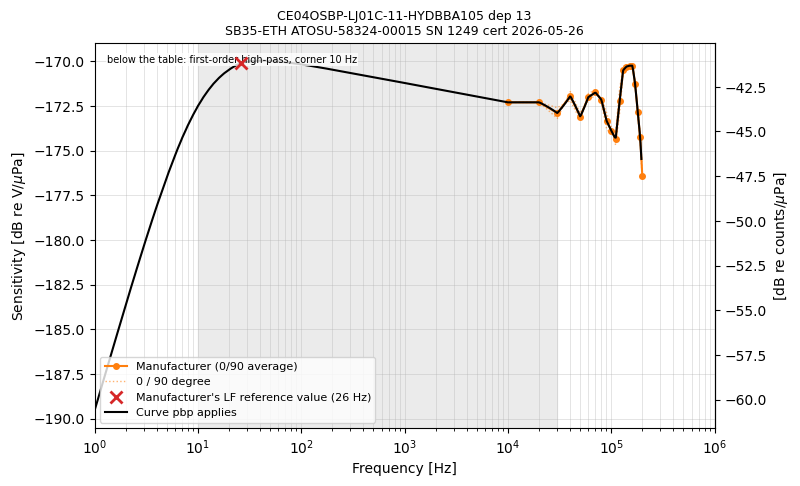

In [3]:
plot_cal("CE04OSBP-LJ01C-11-HYDBBA105", 13);

Previewing the cert's 26 Hz value (-170.1 dB on `ATOSU-58324-00015__20231213`, this deployment's
cert) before it goes into the spec:

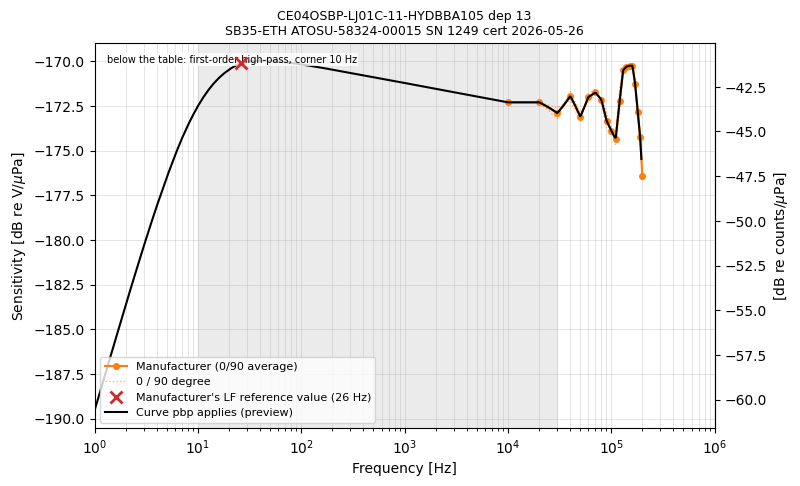

In [4]:
plot_cal("CE04OSBP-LJ01C-11-HYDBBA105", 13, preview_lf_sens=-170.1);

## Every spec

One overlay per instrument to spot a deployment that disagrees with the rest, then each
deployment on its own.

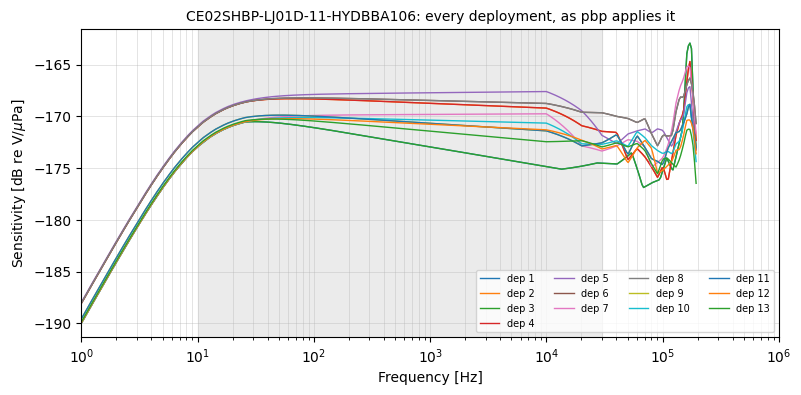

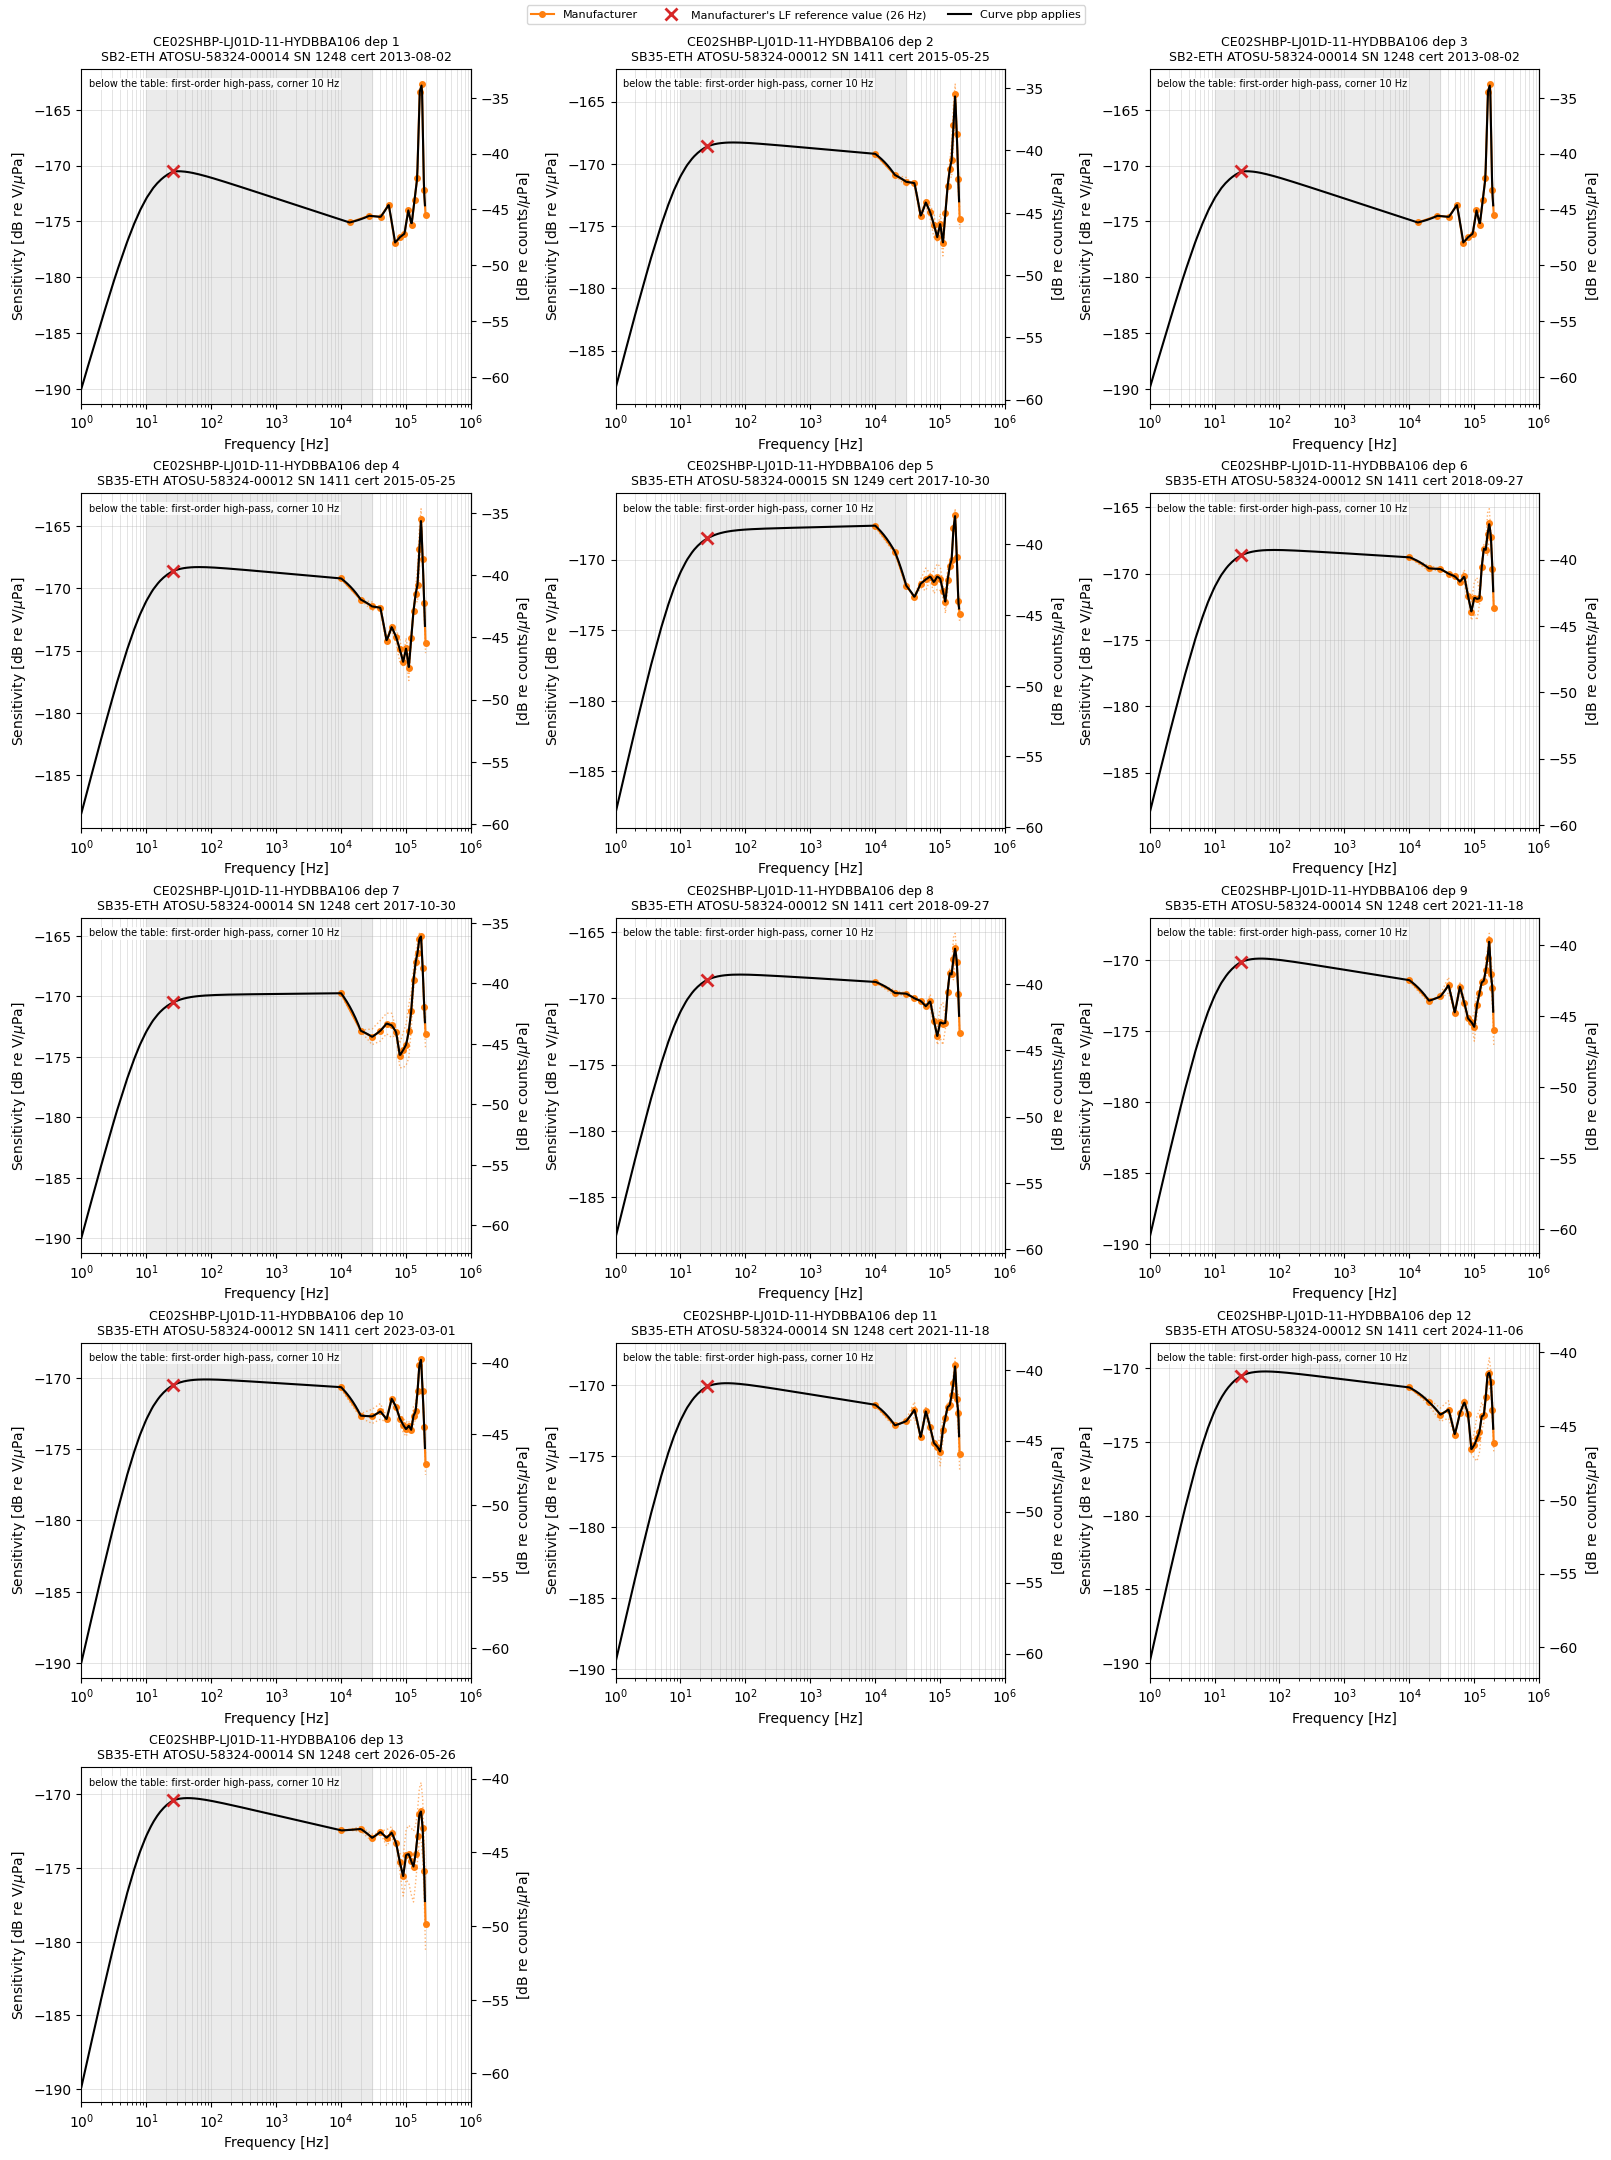

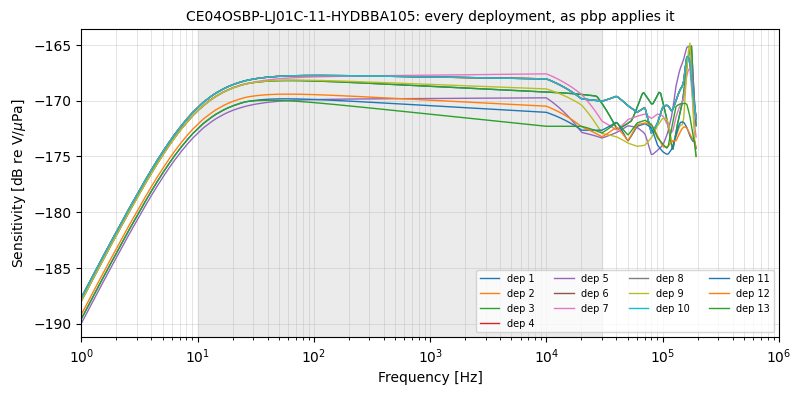

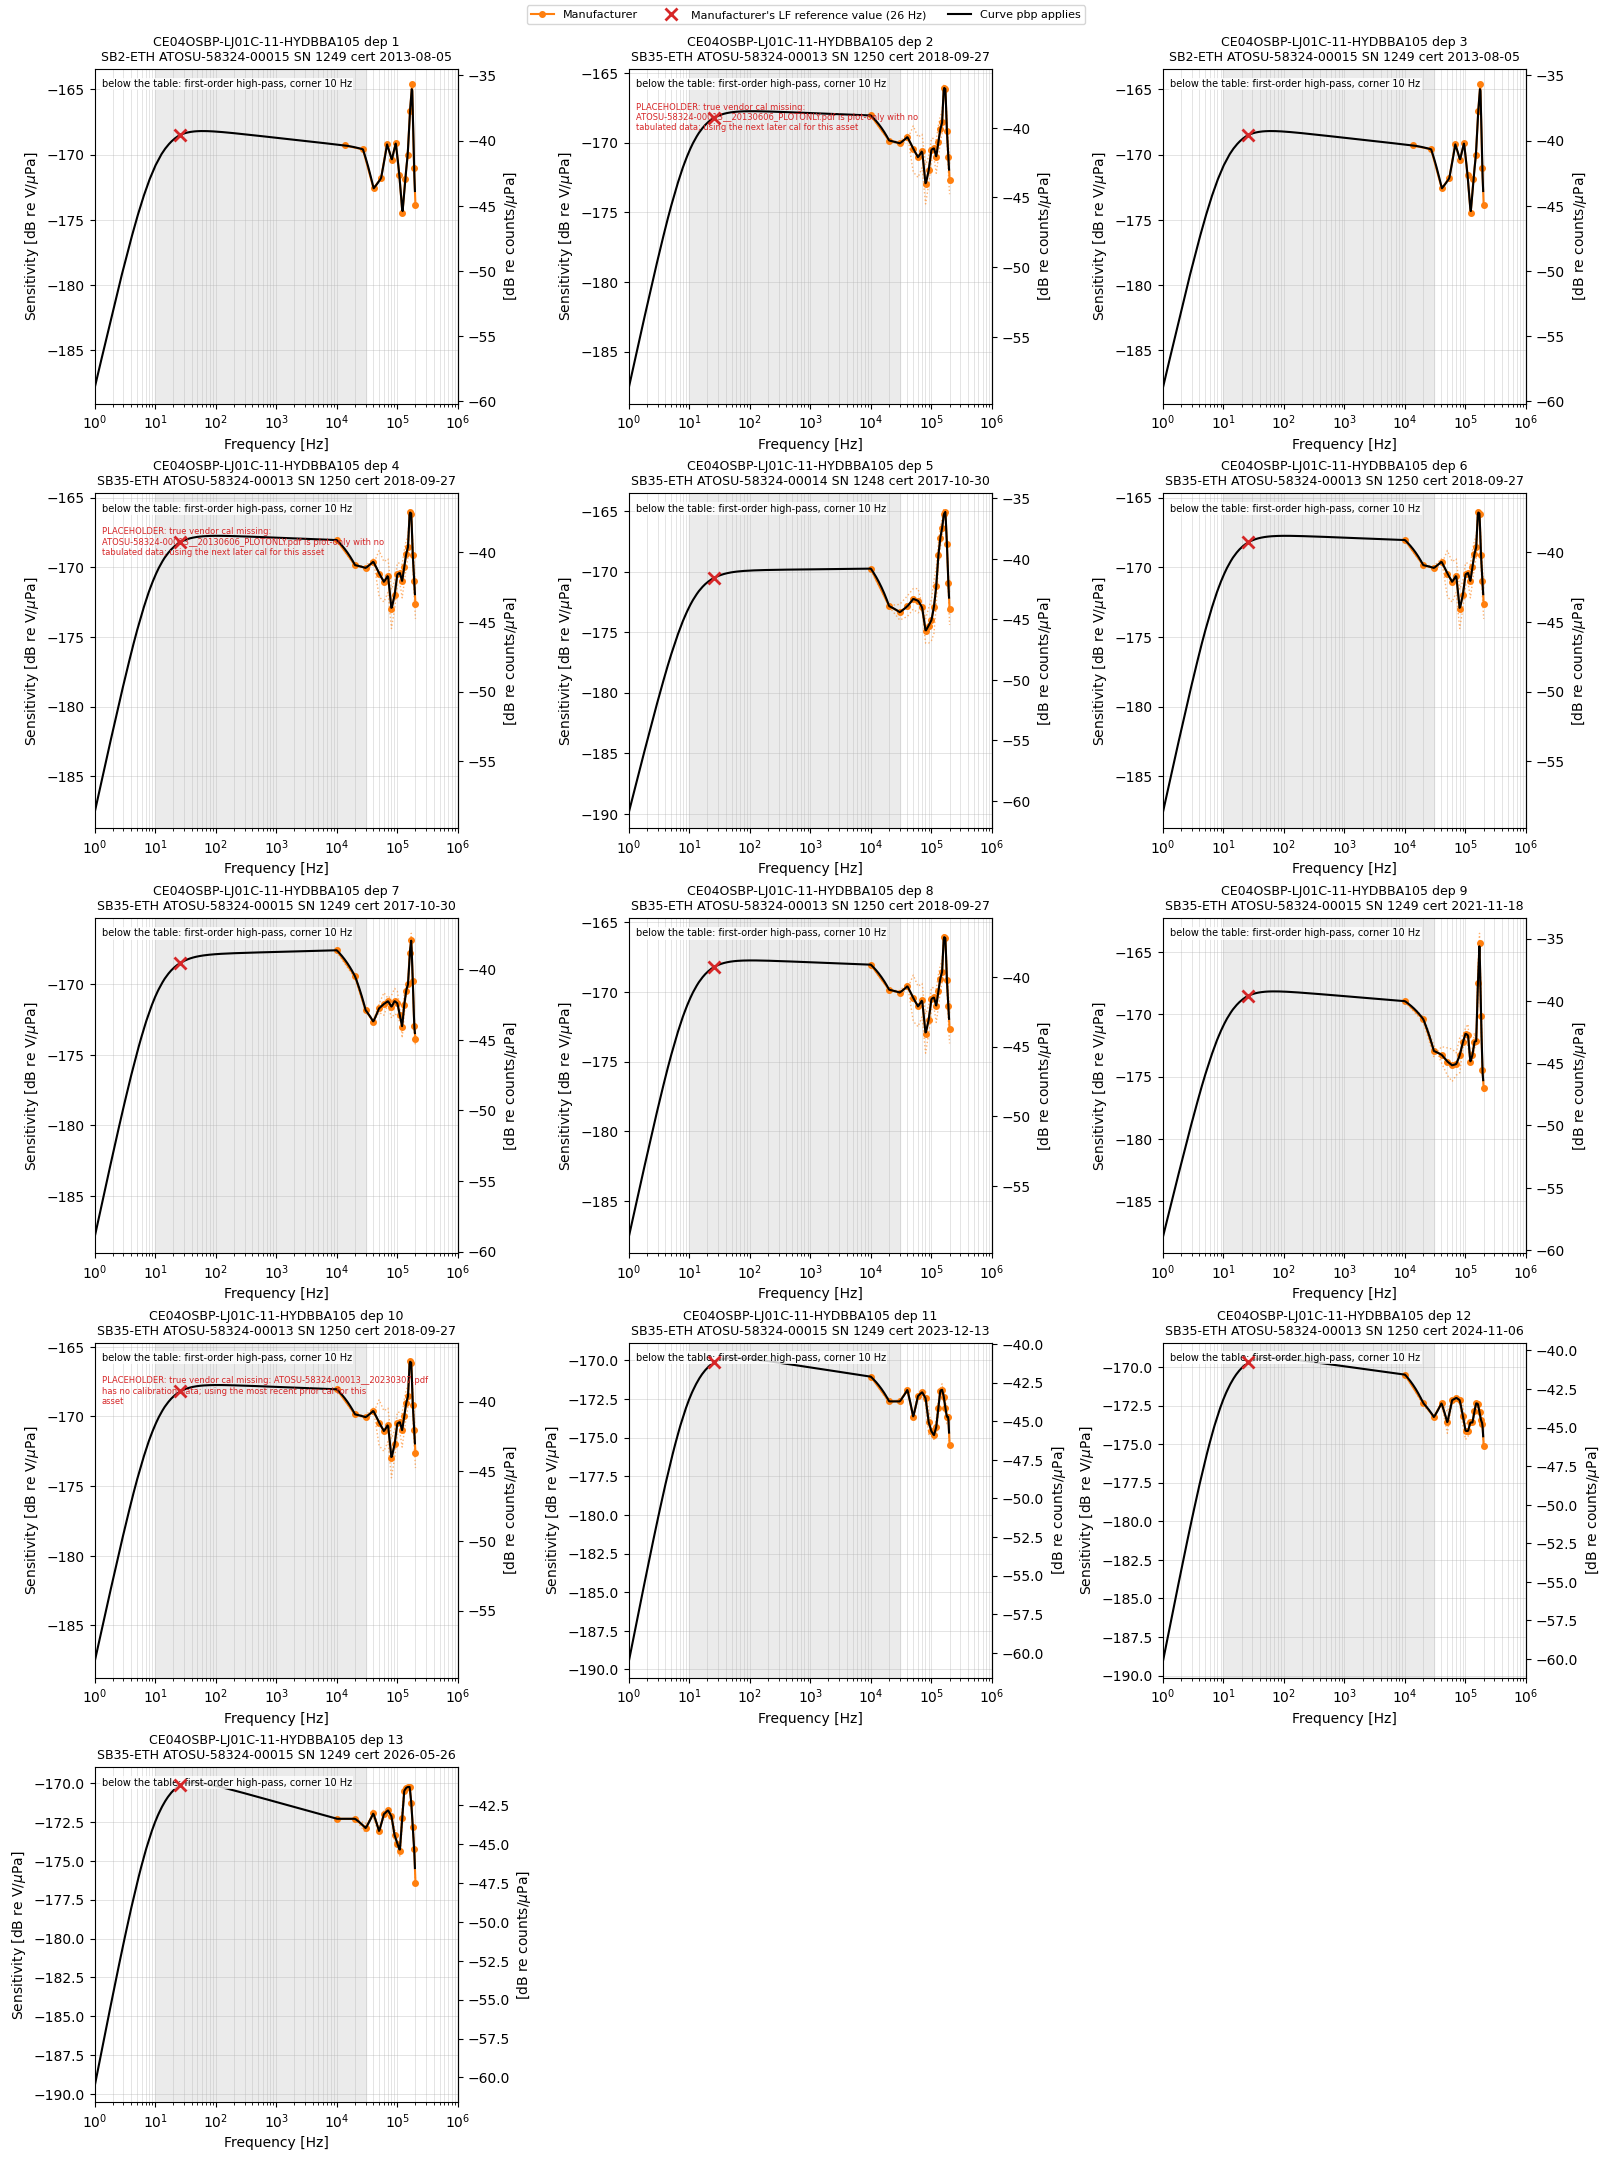

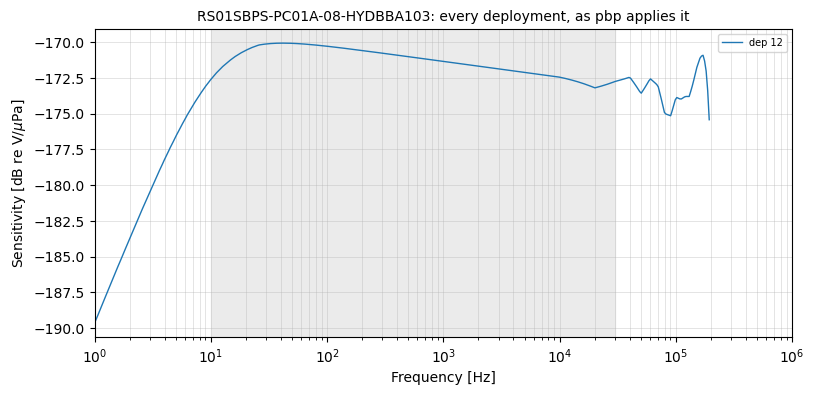

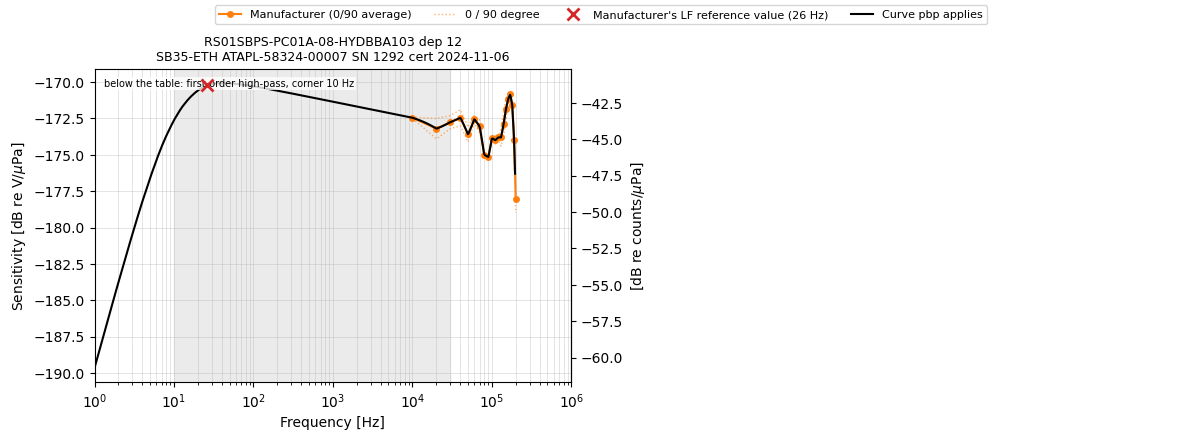

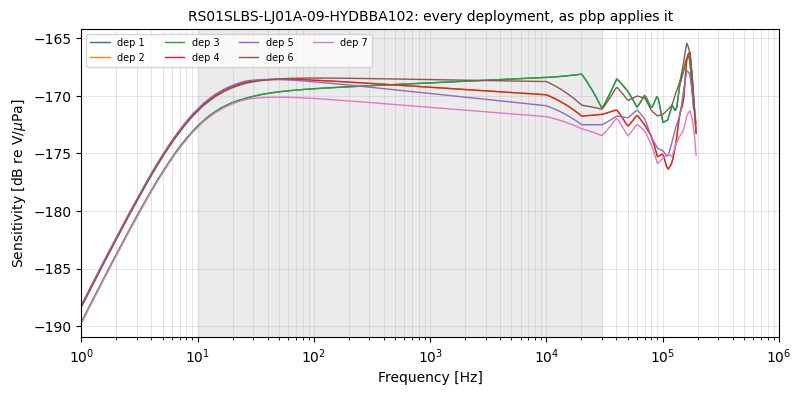

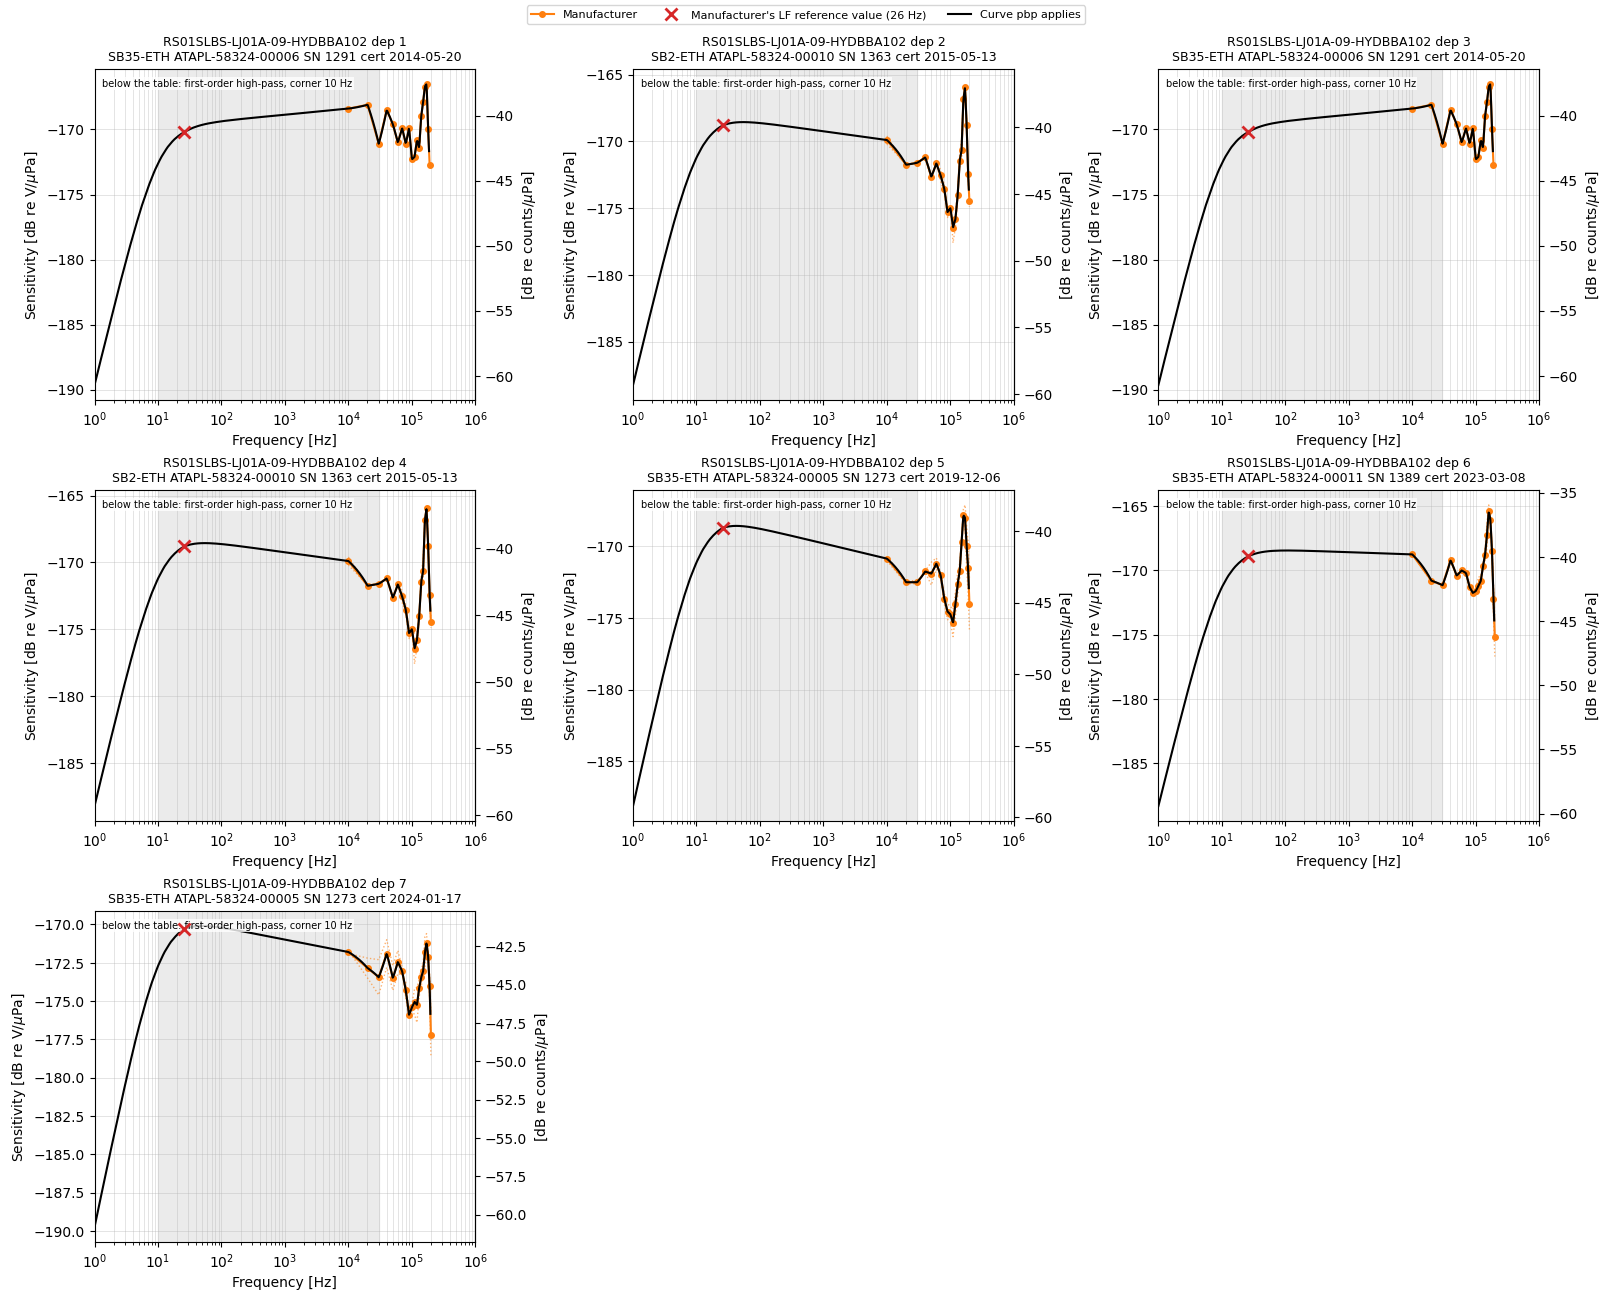

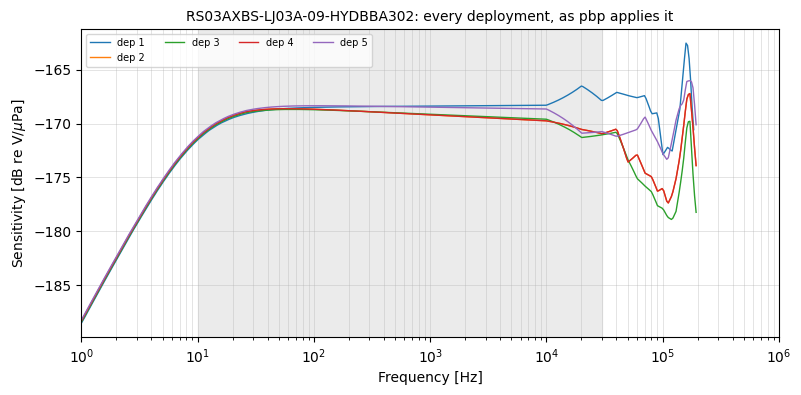

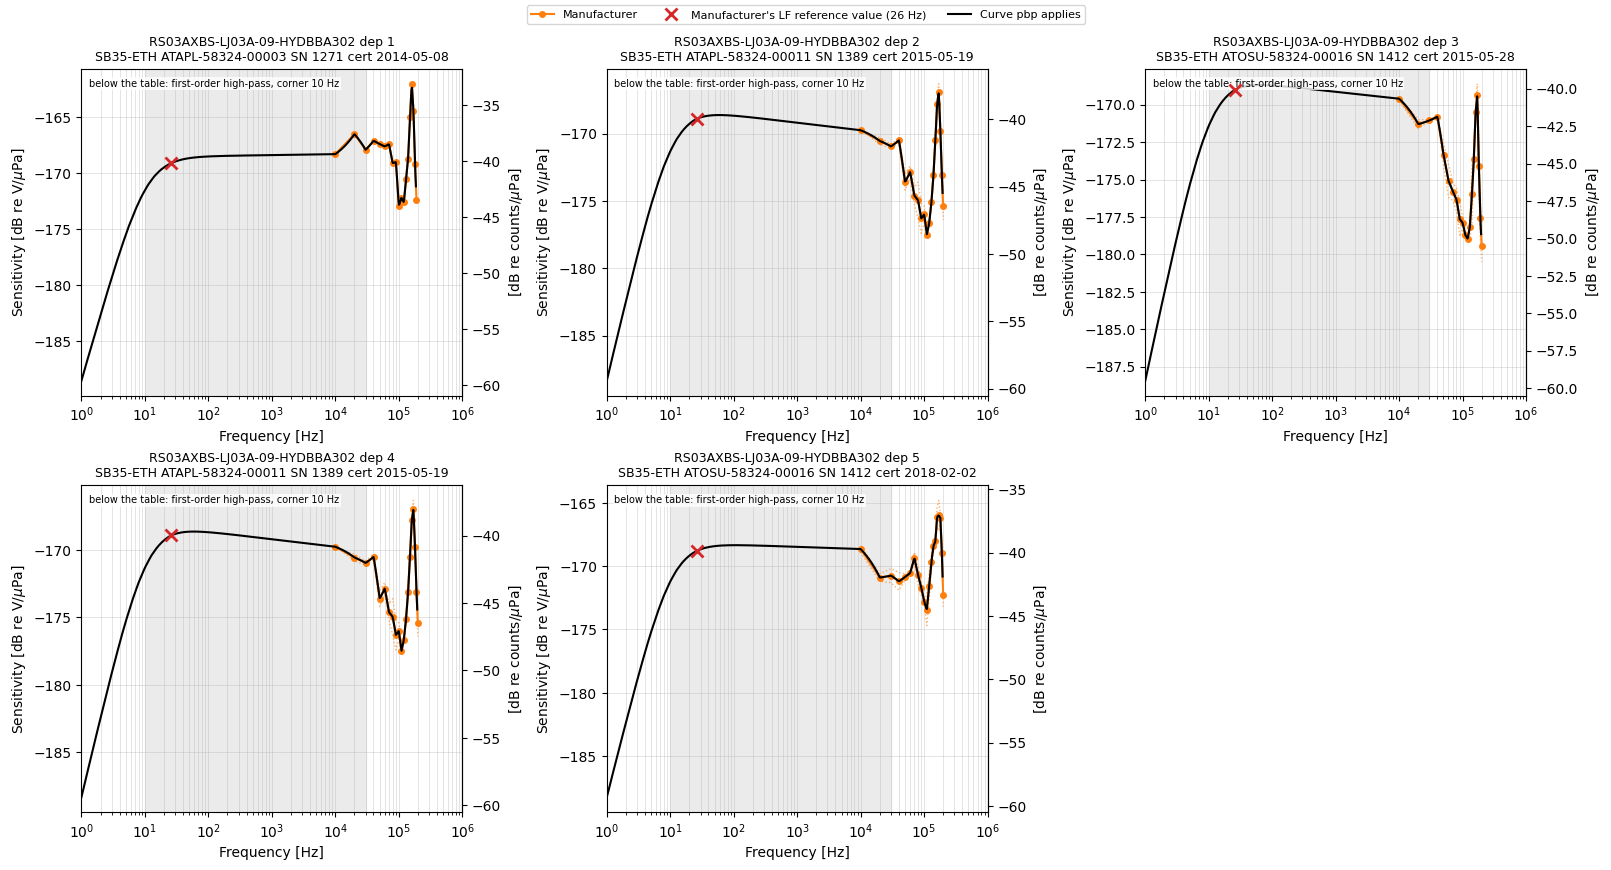

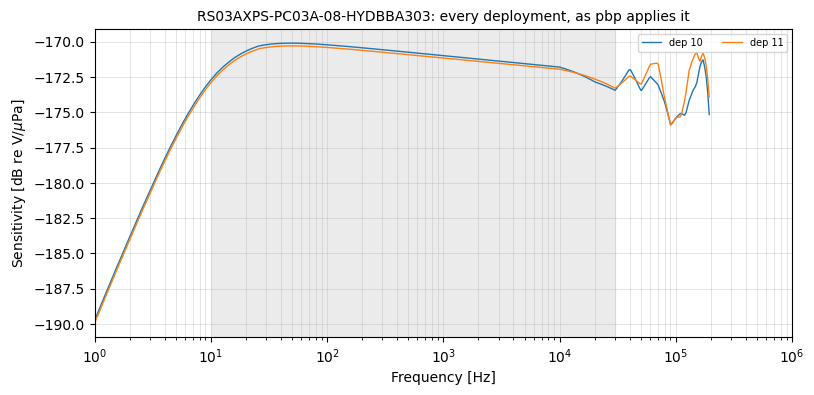

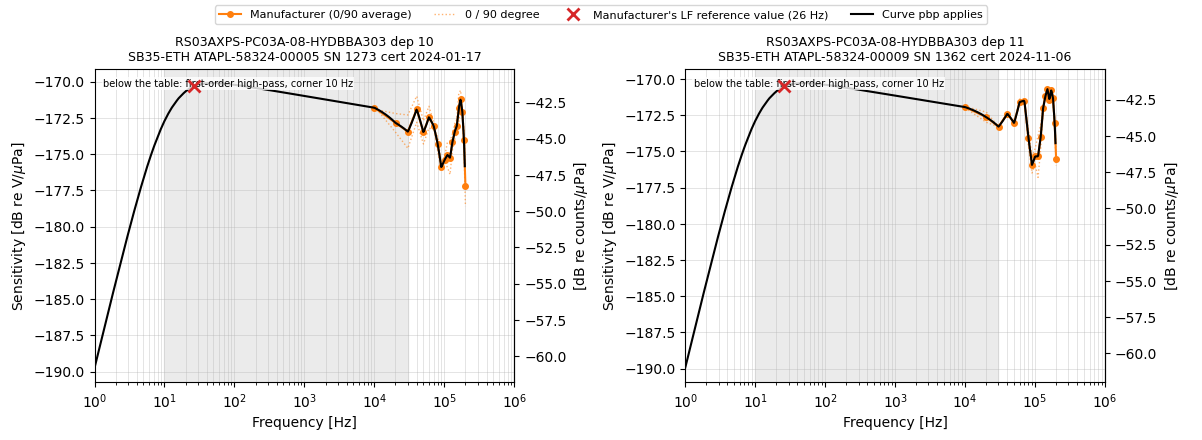

In [5]:
for spec_path in sorted(SPEC_DIR.glob("*.yaml")):
    spec = load_spec(spec_path)
    deps = sorted(spec.deployments, key=int)

    fig, ax = plt.subplots(figsize=(9, 4))
    for dep in deps:
        ds = dataset_for(spec, dep, spec_path)
        f = np.logspace(0, math.log10(float(ds.frequency[-1])), 400)
        ax.plot(f, ds.sensitivity.interp(frequency=f), lw=1, label=f"dep {dep}")
    ax.axvspan(*FREQ_LIMS, color="0.92", zorder=0)
    ax.set_xscale("log"); ax.set_xlim(1, 1e6); ax.grid(True, which="both", lw=0.4, alpha=0.6)
    ax.set_xlabel("Frequency [Hz]"); ax.set_ylabel("Sensitivity [dB re V/$\\mu$Pa]")
    ax.set_title(f"{spec.refdes}: every deployment, as pbp applies it", fontsize=10)
    ax.legend(fontsize=7, ncol=4)
    plt.show()

    ncols = 3
    nrows = math.ceil(len(deps) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4.3 * nrows), squeeze=False, layout="constrained")
    for ax, dep in zip(axes.flat, deps):
        plot_cal(spec.refdes, dep, ax=ax)
    for ax in axes.flat[len(deps):]:
        ax.remove()
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="outside upper center", ncol=4, fontsize=8)
    plt.show()